# Collective Coordinate Method

***

The `tostada.Optimization` module can be used to optimize a point distribution via a reciprocal-space (structure factor) optimization. 
The objective function for the optimization is described as:
$ \phi (r^N) = \sum_q \left(S(q) - S_{\text{target}}(q)\right)^2 $

<span style="color:red">The optimization can either be performed to match a target structure factor or simply supress structure factor in a given region in reciprocal-space.</span>

In this notebook, we will optimize two point distributions of `self.BoxSize`=$[5,5,0] \ \mu\text{m}$: 

1) One with a target structure factor obtained from a large-scale (size 20 $\mu\text{m}$) random sequential absorption (RSA) process (near Hyperuniform systems). Output is a `PointDistribution` object with same statistics as the original RSA distribution.

2) One without target structure factor. Output is a `PointDistribution` object with $S(q)=0$ for a subset of wave-vectors (stealthy hyperuniform systems)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tostada as tost

***

### 1) With target:

The idea is to use structure factor obtained from a fairly large disordered arrangement of particles as a target for optimization for fewer particles in a smaller sample. Essentially, the final outcome will have identical properties but in a much smaller sample. The target can either be obtained from a simulation itself or a structure factor from Scanning Electron Microscope (SEM) image of a fabricated sample.

For simplicity, here we shall simulate a large RSA sample using `tostada.Pointprocess` and use that as a target.

First, let us define a point-process that describes the box size, diameter and mean interparticle distance we need in the large sample.

In [ ]:
large_sample_rsa = tost.Pointprocess(BoxSize=20, #square box of size 20 x 20 microns
                                diameter=0.4, #diameter = 0.4 microns
                                ax=0.5) #mean-interparticle distance = 0.5 microns

Now run the `self.RandomSequentialAdsorption()` to generate a `tostada.PointDistribution` object. 

In [4]:
rsa_target = large_sample_rsa.RandomSequentialAdsorption(sdev_histo=0.065) # Caution: runs for over 3mins 

Estimated particles to be deposited=1600 with mean inter-particle distance=0.5


number of experiments:9999990): |█████████████████████████████-| 100.0% Current FF=3.925 of 4.000


Since the distribution is near-hyperuniform, one can use `self.Hyperuniformity_data()` to access the hyperuniformity details.

In [5]:
rsa_target.Hyperuniformity_data(dkx=2*np.pi/40)

2025-07-22 08:48:54.409694: W external/xla/xla/service/gpu/nvptx_compiler.cc:765] The NVIDIA driver's CUDA version is 12.4 which is older than the ptxas CUDA version (12.9.41). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


Spectral Width of the structural peak=68.33982350919155
Hyperuniformity of the structure = 0.029239967323425764


(np.float64(68.33982350919155), np.float64(0.029239967323425764))

Use `tostada.plot_util.Visualize` to visualize the reciprocal-space.

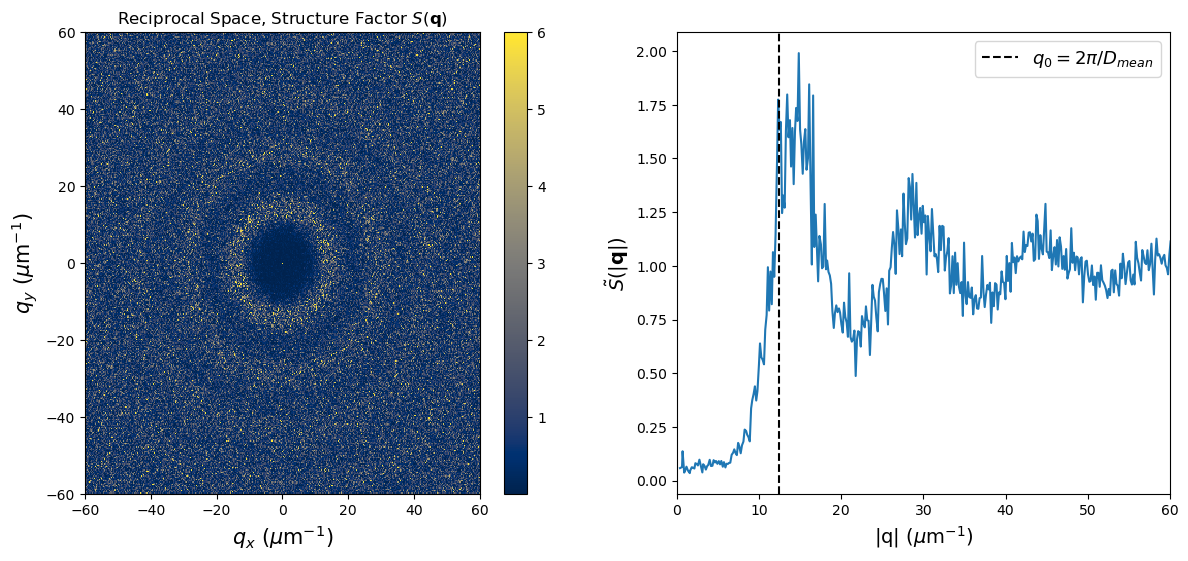

In [ ]:
Fig = tost.Visualize(rsa_target)
ax = Fig.plot_reciprocal_space(vmax=6)
ax[1].axvline(x=2*np.pi/rsa_target.dmean,linestyle='--',color='black',label='$q_0=2\\pi/D_{mean}$')
ax[1].legend(fontsize=13)

Given the target defined, let us generate a smaller sample with same diameter and same interparticle distance.

In [ ]:
small_sample_rsa = tost.Pointprocess(BoxSize=5, #square box of size 5 x 5 microns
                                diameter=rsa_target.diameter, #diameter directly imported from the first run.
                                ax=rsa_target.dmean) #mean-interparticle distance imported from the first run.

In [8]:
rsa_small = small_sample_rsa.RandomSequentialAdsorption(sdev_histo=0.06)

Estimated particles to be deposited=98 with mean inter-particle distance=0.5047544651250687


number of experiments:2959900): |------------------------------| 3.0% Current FF=3.920 of 3.925


Now define the optimization problem using `tostada.Optimization`. It directly takes PointDistribution as an input to access relevant quantities.

In [ ]:
opt = tost.Optimization(rsa_small,Qmax=50)

Since the large sample (size $L$) has a different reciprocal-space frequency ($dq = 2\pi/L$) than the smaller sample ($dq'=2\pi/L'$), the structure factor of the target must be interpolated onto the other grid. 

Note: The $Qmax$ in the Optimization must be smaller than $\sqrt{2}Q_{\text{max},L}$ for a well-defined interpolation range.

In [10]:
Target = opt.interpolate_Target1D(rsa_target.Sq_averaged)
opt.Target = Target

Now, let's optimize!

In [11]:
opt_rsa = opt.optimize(q_f = rsa_target.Q_from_chi(0.7)) #Caution: May run for over 5 minutes

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =          198     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.90549D-01    |proj g|=  3.11085D-01

At iterate    1    f=  6.88001D-02    |proj g|=  1.15654D-01

At iterate    2    f=  3.77832D-02    |proj g|=  4.75875D-02

At iterate    3    f=  2.54609D-02    |proj g|=  3.04815D-02

At iterate    4    f=  1.52456D-02    |proj g|=  3.52303D-02

At iterate    5    f=  1.08884D-02    |proj g|=  3.65031D-02

At iterate    6    f=  7.07618D-03    |proj g|=  1.20904D-02

At iterate    7    f=  5.32406D-03    |proj g|=  1.18679D-02

At iterate    8    f=  3.95188D-03    |proj g|=  7.86615D-03

At iterate    9    f=  3.39058D-03    |proj g|=  1.09681D-02

At iterate   10    f=  2.75667D-03    |proj g|=  6.41396D-03

At iterate   11    f=  2.35587D-03    |proj g|=  5.30235D-03

At iterate   12    f=  1.94381D-03    |proj g|=  5.08833D-03

At iterate   13    f=  1.8

The optimal positions are saved in `self.opt_positions`. These can now be used to define `PointDistribution`.

In [ ]:
rsa_opt = tost.PointDistribution(opt.opt_positions, diameter=rsa_small.diameter, BoxSize=rsa_small.BoxSize)

Now, let's visualize the point distribution and its structure factor.

<Axes: title={'center': 'Point Distribution, mean interparticle distance = 0.502518907629606'}, xlabel='X ($\\mu$m)', ylabel='Y ($\\mu$m)'>

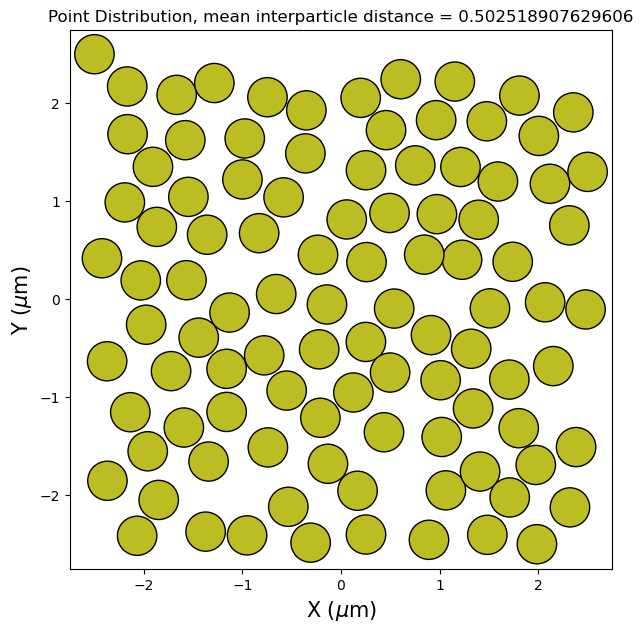

In [ ]:
Fig = tost.Visualize(rsa_opt)
Fig.plot_distribution()

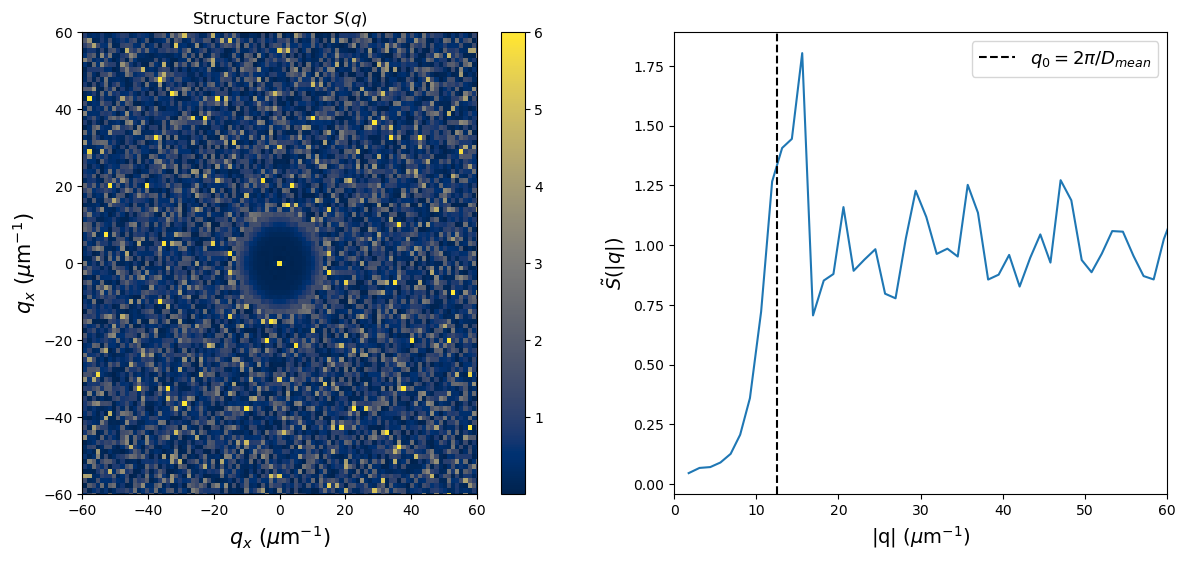

In [15]:
ax = Fig.plot_reciprocal_space(vmax=6)
ax[1].axvline(x=2*np.pi/rsa_small.dmean,linestyle='--',color='black',label='$q_0=2\\pi/D_{mean}$')
ax[1].legend(fontsize=13)

In [16]:
rsa_opt.Hyperuniformity_data(dkx=2*np.pi/10)

Spectral Width of the structural peak=70.2440471013387
Hyperuniformity of the structure = 0.025131656886065896


(np.float64(70.2440471013387), np.float64(0.025131656886065896))

***

### 2) Without the target:

The optimization can be used without the target. The optimization will now minimize the structure factor for $0 < q < Q_{max}$.

In [ ]:
opt = tost.Optimization(rsa_small,Qmax=50)

In [ ]:
opt_rsa = opt.optimize(q_f = rsa_target.Q_from_chi(0.43)) #relatively cheaper computations than the target one.

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =          200     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  5.85717D-02    |proj g|=  1.09573D-01

At iterate    1    f=  2.01447D-02    |proj g|=  2.93878D-02

At iterate    2    f=  1.35508D-02    |proj g|=  1.96958D-02

At iterate    3    f=  5.79175D-03    |proj g|=  9.84174D-03

At iterate    4    f=  2.71018D-03    |proj g|=  3.72271D-03

At iterate    5    f=  1.04113D-03    |proj g|=  2.27425D-03

At iterate    6    f=  3.86018D-04    |proj g|=  1.26084D-03

At iterate    7    f=  1.29107D-05    |proj g|=  1.08334D-03

At iterate    8    f= -2.28900D-04    |proj g|=  1.05576D-03

At iterate    9    f= -3.92857D-04    |proj g|=  6.10965D-04

At iterate   10    f= -5.46184D-04    |proj g|=  4.83301D-04

At iterate   11    f= -6.49208D-04    |proj g|=  5.51583D-04

At iterate   12    f= -7.27512D-04    |proj g|=  4.03397D-04

At iterate   13    f= -7.8

In [ ]:
rsa_opt = tost.PointDistribution(opt.opt_positions, diameter=rsa_small.diameter, BoxSize=rsa_small.BoxSize)

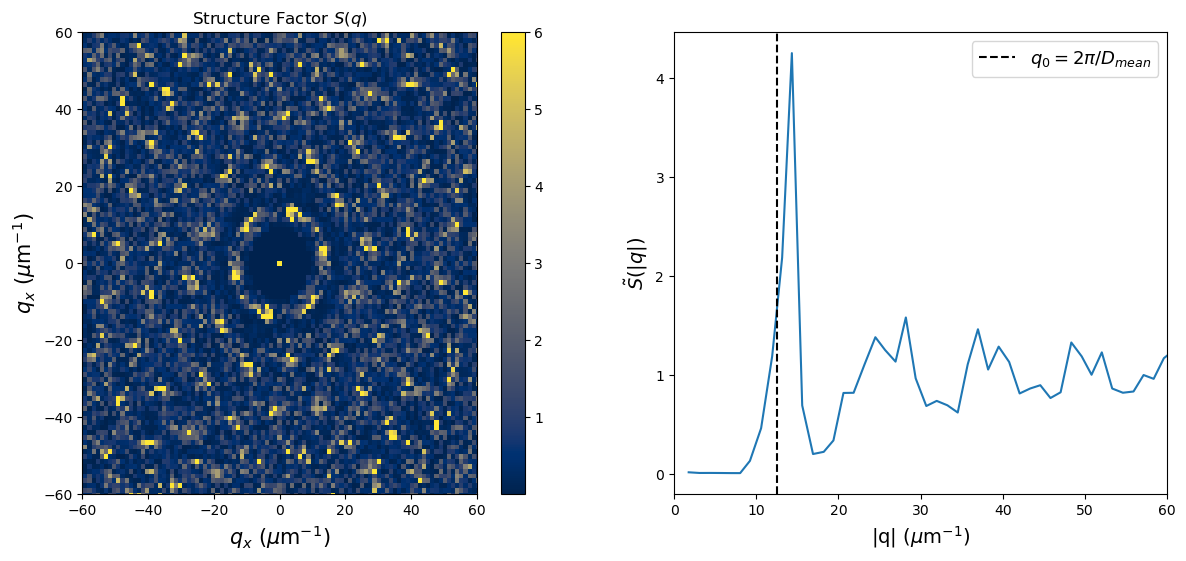

In [ ]:
Fig = tost.Visualize(rsa_opt)
ax = Fig.plot_reciprocal_space(vmax=6)
ax[1].axvline(x=2*np.pi/rsa_small.dmean,linestyle='--',color='black',label='$q_0=2\\pi/D_{mean}$')
ax[1].legend(fontsize=13)

From the structure factor plots, it can be seen that $S(q) = 0$ for $0 < q < Q_{max}$, thus implying zero scattering for a range of wave-vectors in the single-scattering approximation. The width of the region with $S(q)=0$ can be tuned by changing $Q_{max}$. 

In [21]:
rsa_opt.Hyperuniformity_data(dkx=2*np.pi/10)

Spectral Width of the structural peak=1.1831163167953491
Hyperuniformity of the structure = 0.003606091879303667


(np.float64(1.1831163167953491), np.float64(0.003606091879303667))